In [ ]:
#maybe dont run this on your system...
!mamba install fastcore=1.5.29 

warning  libmamba 'repo.anaconda.com', a commercial channel hosted by Anaconda.com, is used.
    
warning  libmamba Please make sure you understand Anaconda Terms of Services.
    
warning  libmamba See: https://legal.anaconda.com/policies/en/
[+] 0.0s
[+] 0.1s
pkgs/main/noarch ---------------------------   0.0 B /  ??.?MB @  ??.?MB/s  0.0s
pkgs/main/osx-64 ---------------------------   0.0 B /  ??.?MB @  ??.?MB/s  0.0s
pkgs/r/noarch    ---------------------------   0.0 B /  ??.?MB @  ??.?MB/s  0.0s
pkgs/r/osx-64    ━━━━━━━━╸━━━━━━━━━━━━━━━╸━━   0.0 B /  ??.?MB @  ??.?MB/s  0.0s
Pinned packages:

  - python=3.10


Transaction

  Prefix: /Users/zoe/.local/share/mamba/envs/lab_env

  Updating specs:

   - fastcore=1.5.29


  Package     Version  Build            Channel         Size
──────────────────────────────────────────────────────────────
  Install:
──────────────────────────────────────────────────────────────

  + fastcore   1.5.29  py310hecd8cb5_1  pkgs/main     Cached

  Summar

In [1]:
%load_ext autoreload
%autoreload 2

import os
os.environ["SYNTHCITY_DEVICE"] = "cpu"

import tapas
from tapas.attacks.set_classifiers import RandomTargetedQueryFeature
from utils.my_attack import MyAttack
from utils.benchmark_pipeline import BenchmarkPipeline
from utils.benchmark_metric import AUCMetric
from utils.tapas.tapas_data_processors import AdultDataProcessor

import random



from reprosyn.methods import DS_PRIVBAYES
from reprosyn.methods import DS_BAYNET
from utils.basegenerators import BenchmarkGenerator, ReprosynGenerator, Raw
from utils.customgenerators import SynthcityGenerator, SDVGenerator
from sdv.single_table import GaussianCopulaSynthesizer

/Users/zoe/.local/share/mamba/envs/tapas-upgrade/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[KeOps] Warning : CUDA libraries not found or could not be loaded; Switching to CPU only.


In [2]:
gen1 = ReprosynGenerator(DS_PRIVBAYES, label="PrivBayes", epsilon=1.0)
repr(gen1)

'PrivBayes_epsilon=1.0'

In [3]:
gen2 = SynthcityGenerator("uniform_sampler", label="uniform_sampler")
repr(gen2)

'uniform_sampler_random_state=42'

In [4]:
gen3 = Raw()
repr(gen3)

'Raw'

In [5]:
gen4 = SDVGenerator(GaussianCopulaSynthesizer, label="GaussianCopulaSynthesizer")
repr(gen4)

'GaussianCopulaSynthesizer'

In [ ]:
# !pip install tf_keras

4522
estimating categorical probs
estimating approx kdes(histogram)
[0.017256637168141593]
Attacking : GaussianCopulaSynthesizer
Generate datasets
[False, True, True, False, True, False, False, True, True, False, True, False, True, False, True, False, False, True, True, False, True, False, False, True, True, False, False, True, False, True, False, True, True, False, False, True, False, True, True, False, False, True, False, True, True, False, True, False, True, False, False, True, False, True, True, False, False, True, True, False, True, False, True, False, True, False, True, False, False, True, True, False, True, False, True, False, False, True, False, True, True, False, True, False, True, False, True, False, False, True, True, False, False, True, True, False, False, True, False, True]
COMPLEXITY:  2
COMPLEXITY:  10
COMPLEXITY:  20
COMPLEXITY:  50
COMPLEXITY:  100


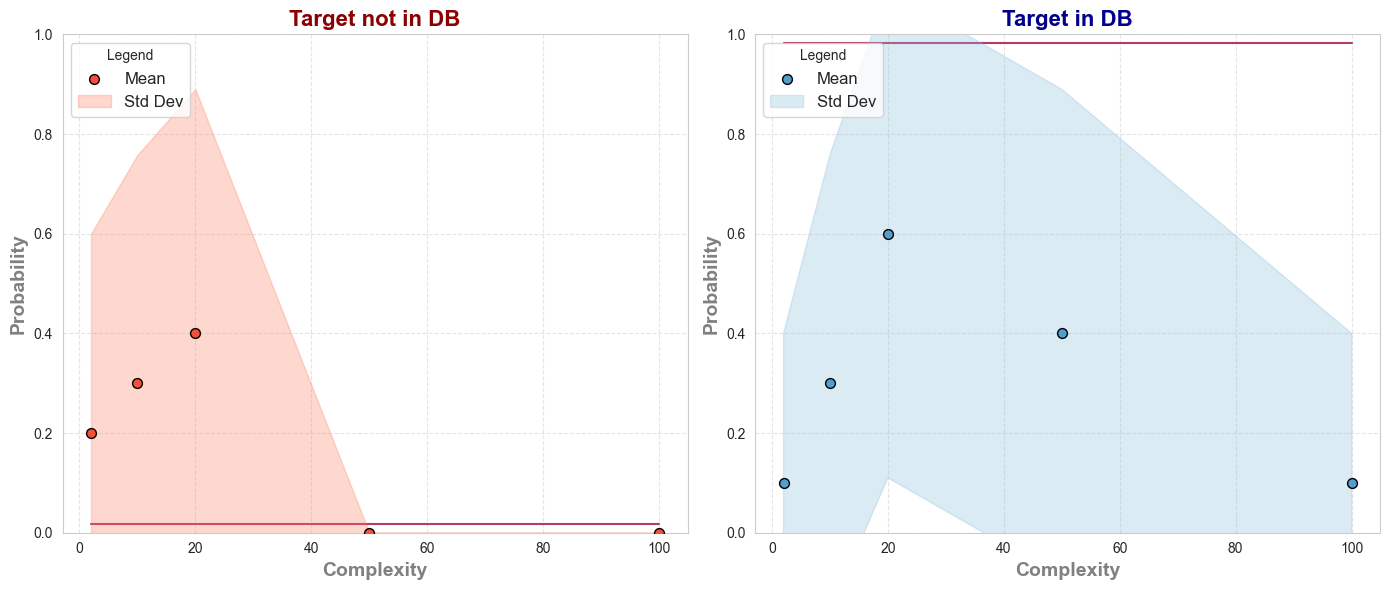

----[Benchmark ranks]----
GaussianCopulaSynthesizer : D, 0.6127551020408163
----[Printing]----
[{'Model': GaussianCopulaSynthesizer, 'Speed': 0.0037011998206113294, 'Final_Score': 'D'}]


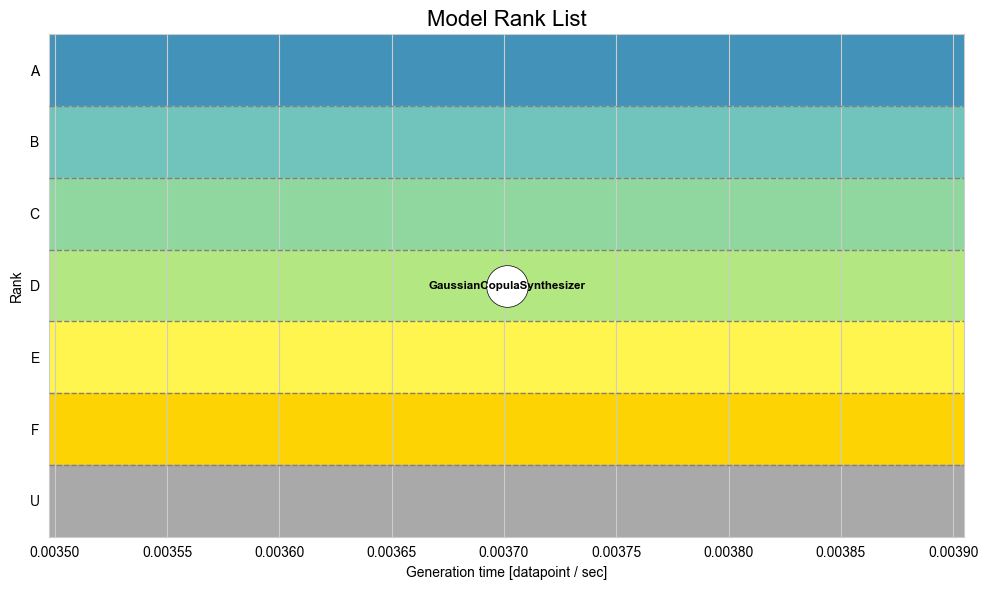

In [6]:
#TEST PIPELINE
data = tapas.datasets.TabularDataset.read("data/adult")
data = AdultDataProcessor.process_tapas_tabulardataset(data)
data = data.sample(frac = 0.1)  #downsample the data 
print(len(data.data))
ind = [int(random.random() * len(data.data))]

target_record = data.get_records(ind)
data.drop_records(ind, in_place=True)

attack = MyAttack(100, features=RandomTargetedQueryFeature(target_record,4,2000))


pipeline = BenchmarkPipeline(data, attack, [gen4], target_record=target_record)
benchmarking_metric = AUCMetric([0,0.17,0.33,0.50,0.67,0.83])
pipeline.run([2,10,20,50,100], 10, 2, plot_style = "double", benchmarking_metric=benchmarking_metric)